# Dataset

### Normal Sinus Rhythm RR Interval Database

This database includes beat annotation files for 54 long-term ECG recordings of subjects in normal sinus rhythm (30 men, aged 28.5 to 76, and 24 women, aged 58 to 73). The original ECG recordings (not available) were digitized at 128 samples per second, and the beat annotations were obtained by automated analysis with manual review and correction.

Reference: https://physionet.org/content/nsr2db/1.0.0/
Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P.C., Mark, R., Mietus, J.E., Moody, G.B., Peng, C.K. and Stanley, H.E., 2000. PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

# Load Data

In [2]:
from utils import *
import numpy as np
import matplotlib.pyplot as plt

data_dir = "physionet.org/files/nsr2db/1.0.0"
rr_data = load_rr_intervals(data_dir)

  nsr001: 106464 beats, mean HR = 79.0 bpm
  nsr002: 111334 beats, mean HR = 79.5 bpm
  nsr003: 97585 beats, mean HR = 69.3 bpm
  nsr004: 97821 beats, mean HR = 70.5 bpm
  nsr005: 116773 beats, mean HR = 81.7 bpm
  nsr006: 102662 beats, mean HR = 74.3 bpm
  nsr007: 106792 beats, mean HR = 76.1 bpm
  nsr008: 107739 beats, mean HR = 75.4 bpm
  nsr009: 102861 beats, mean HR = 71.8 bpm
  nsr010: 96252 beats, mean HR = 70.1 bpm
  nsr011: 115900 beats, mean HR = 81.5 bpm
  nsr012: 98905 beats, mean HR = 69.1 bpm
  nsr013: 115757 beats, mean HR = 82.3 bpm
  nsr014: 111896 beats, mean HR = 78.2 bpm
  nsr015: 100961 beats, mean HR = 75.9 bpm
  nsr016: 94767 beats, mean HR = 77.2 bpm
  nsr017: 100959 beats, mean HR = 70.4 bpm
  nsr018: 107982 beats, mean HR = 77.3 bpm
  nsr019: 122822 beats, mean HR = 85.7 bpm
  nsr020: 136481 beats, mean HR = 97.7 bpm
  nsr021: 103875 beats, mean HR = 72.5 bpm
  nsr022: 81720 beats, mean HR = 57.8 bpm
  nsr023: 112094 beats, mean HR = 78.2 bpm
  nsr024: 101102 

# Step 1: build the cumulative time series B(i) from the detrended and normalised heart beat time series b(i)

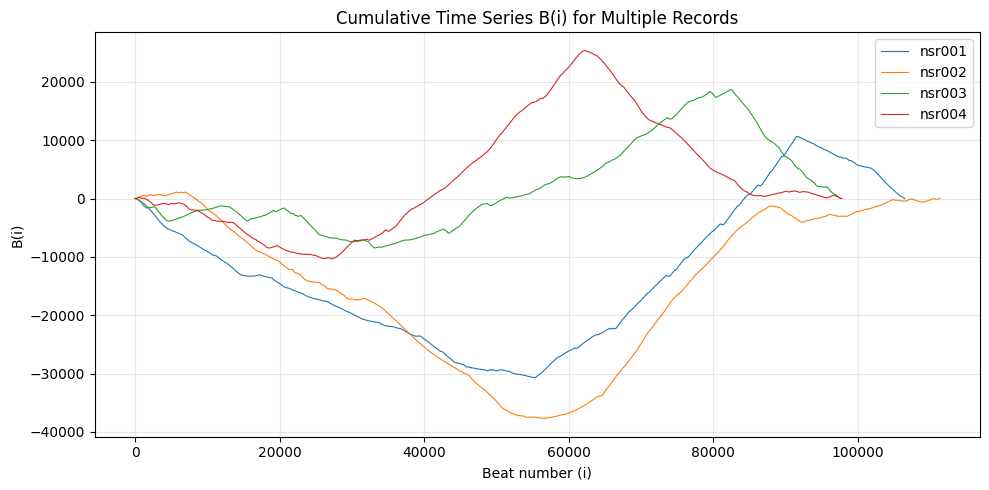

In [8]:
# Dictionaries to store the normalized b(i) and cumulative B(i) time series
b_data = {}
B_data = {}

for record_name, rr in rr_data.items():
    # 1. Calculate mean (\mu) and standard deviation (\sigma)
    mu = np.mean(rr)
    sigma = np.std(rr)
    
    # 2. Normalize the RR intervals to get b(i)
    b_i = (rr - mu) / sigma
    b_data[record_name] = b_i
    
    # 3. Integrate (cumulative sum) to get B(i)
    B_i = np.cumsum(b_i)
    B_data[record_name] = B_i

first_n = 4 # Plot the first_n random walks
records_to_plot = list(B_data.keys())[:first_n]

plt.figure(figsize=(10, 5))

for record_name in records_to_plot:
    plt.plot(B_data[record_name], lw=0.8, label=f"{record_name}")

plt.title("Cumulative Time Series B(i) for Multiple Records")
plt.xlabel("Beat number (i)")
plt.ylabel("B(i)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 2 & 3: Polynomial Detrending and Calculating Increments

The paper describes a specific sliding-window technique (related to Detrended Fluctuation Analysis, DFA):
1. Take a sliding window of size $2s$.
2. Fit a polynomial (the paper uses 3rd order) to the data in that window.
3. Subtract the polynomial trend to get the residual fluctuations, $B^*(i)$.
4. Calculate the increment across scale $s$ within that window: $\Delta_s B = B^*(s) - B^*(0)$.
5. Slide the window forward by 1 beat and repeat.

Calculating detrended increments for nsr001 at scale s=64...


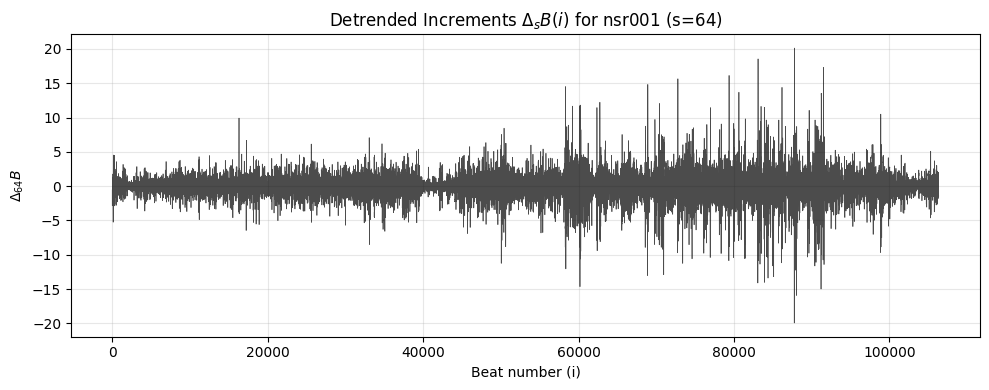

In [ ]:
def get_detrended_increments(B_array: np.ndarray, s: int, order: int=3):
    """
    Extracts detrended increments \\Delta_s B(i) using a sliding window.
    
    B_array: Cumulative time series array
    s: time scale (number of beats)
    order: polynomial order for detrending (paper uses 3rd order)
    """
    N = len(B_array)
    window_size = 2 * s
    increments = []
    
    # x-axis for our local window
    x = np.arange(window_size)
    
    # We slide the window one beat at a time
    for i in range(N - window_size + 1):
        # 1. Grab the local segment of size 2s
        window_data = B_array[i : i + window_size]
        
        # 2. Fit an 'order'-th degree polynomial
        coeffs = np.polyfit(x, window_data, order)
        poly_trend = np.polyval(coeffs, x)
        
        # 3. Calculate deviation from the polynomial fit (B*)
        B_star = window_data - poly_trend
        
        # 4. Calculate the increment at scale s 
        # (In local coordinates, from index 0 to index s)
        delta_B = B_star[s] - B_star[0]
        
        increments.append(delta_B)
        
    return np.array(increments)

# Let's test it on a single record at a single scale (e.g., s = 64 beats)
s_test = 64
test_record = list(B_data.keys())[0]
B_test = B_data[test_record]

print(f"Calculating detrended increments for {test_record} at scale s={s_test}...")
delta_B_s64 = get_detrended_increments(B_test, s=s_test, order=3)

# Plot the resulting increments
plt.figure(figsize=(10, 4))
plt.plot(delta_B_s64, lw=0.5, color='black', alpha=0.7)
plt.title(rf"Detrended Increments $\Delta_s B(i)$ for {test_record} (s={s_test})")
plt.xlabel("Beat number (i)")
plt.ylabel(rf"$\Delta_{{{s_test}}} B$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To really understand what just happened, read this:

Imagine the cumulative heartbeat series $B(i)$ as a **bumpy mountain range**. 

The massive mountains and deep valleys represent slow, macroscopic behavioral changes—like a person waking up, exercising, or falling asleep. The tiny, jagged rocks on the surface represent the intrinsic, beat-to-beat fluctuations of the nervous system. Our goal is to measure the size of these "rocks" over a specific distance $s$ (e.g., 64 steps). If we simply measure our altitude change every 64 steps, our math will be completely overwhelmed by the steep slope of the mountain itself. 

So, we use a clever mathematical trick: we place a sliding window over a section of the path ($2s$), and fit a flexible, smooth curve (the 3rd-order polynomial) to exactly match the shape of the mountain in that specific window. By subtracting that smooth curve from our data, we mathematically **flatten the ground**, temporarily erasing the mountain entirely. Only then, on this newly flattened ground, do we measure the change in height ($\Delta_s B$) over our distance $s$. By sliding this window one beat at a time, we successfully strip away all the massive, slow trends of daily life, leaving behind only the pure, isolated nervous system fluctuations we need to study. 

# Step 4: Build the PDF and find the Fat Tails

If heart rate fluctuations were purely random (like tossing a coin or thermal white noise), the increments we just calculated would perfectly follow a Gaussian (bell curve) distribution. Extreme fluctuations would be statistically impossible. But as we saw in last plot, there are massive spikes. To prove these aren't just outliers, we are going to build a Probability Density Function (PDF) of those increments.

To compare it fairly, we first standardize the data (divide by the standard deviation so the variance is 1). Then, we will fit it with a standard Gaussian, and a non-Gaussian q-Gaussian (which allows for "fat tails"). We will plot this on a logarithmic y-axis because that is the only way to clearly see what happens at the extreme edges (the "tails") of the distribution.

Fitted q-Gaussian parameters: A=0.611, beta=1.948, q=1.565


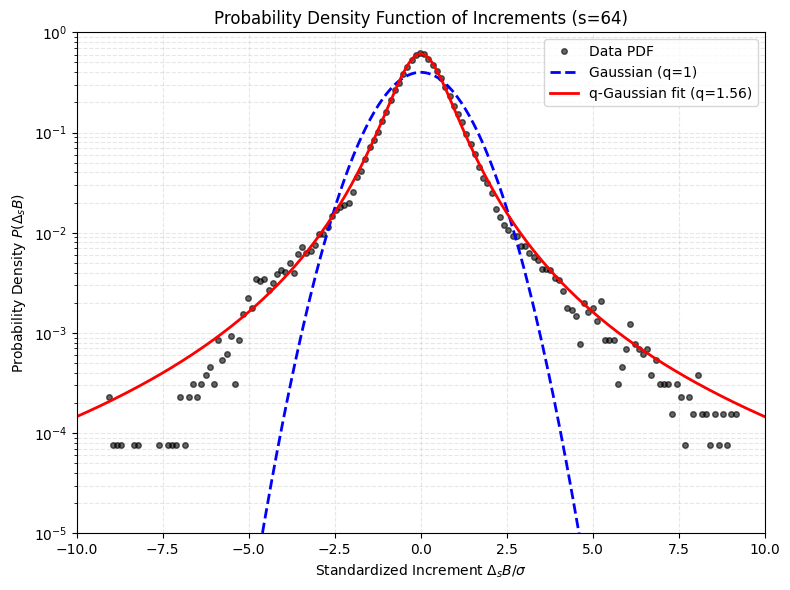

In [ ]:
from scipy.optimize import curve_fit

# 1. Standardize the increments (mean = 0, standard deviation = 1)
std_increments = delta_B_s64 / np.std(delta_B_s64)

# 2. Calculate the Histogram (PDF)
counts, bin_edges = np.histogram(std_increments, bins=150, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Filter out empty bins so we don't take log(0)
mask = counts > 0
x_data = bin_centers[mask]
y_data = counts[mask]

# 3. Define the standard Gaussian (mean=0, std=1)
def gaussian(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# 4. Define the q-Gaussian (from Tsallis statistics)
def q_gaussian(x, A, beta, q):
    # The mathematical form for q-Gaussian
    # When q -> 1, this becomes a standard Gaussian
    # When q > 1, it develops "fat tails"
    return A * (1 - (1 - q) * beta * x**2)**(1 / (1 - q))

# 5. Fit the q-Gaussian to our data
# We provide initial guesses: A=0.4 (peak of Gaussian), beta=0.5, q=1.5
popt, pcov = curve_fit(q_gaussian, x_data, y_data, p0=[0.4, 0.5, 1.5])
A_fit, beta_fit, q_fit = popt

print(f"Fitted q-Gaussian parameters: A={A_fit:.3f}, beta={beta_fit:.3f}, q={q_fit:.3f}")

# 6. Plot the results on a Logarithmic scale
plt.figure(figsize=(8, 6))

# Plot the actual data as scatter points
plt.plot(x_data, y_data, 'o', markersize=4, color='black', alpha=0.6, label='Data PDF')

# Plot the theoretical Gaussian
x_plot = np.linspace(-15, 15, 500)
plt.plot(x_plot, gaussian(x_plot), '--', color='blue', lw=2, label='Gaussian (q=1)')

# Plot our fitted q-Gaussian
plt.plot(x_plot, q_gaussian(x_plot, *popt), '-', color='red', lw=2, 
         label=f'q-Gaussian fit (q={q_fit:.2f})')

plt.yscale('log') # This is crucial!
plt.xlim(-10, 10)
plt.ylim(1e-5, 1)

plt.title(f"Probability Density Function of Increments (s={s_test})")
plt.xlabel(r"Standardized Increment $\Delta_s B / \sigma$")
plt.ylabel(r"Probability Density $P(\Delta_s B)$")
plt.legend()
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

This plot is the most compelling evidence that tells us the heart isn't just acting randomly! If the heart worked like a coin toss, our data points would follow the blue dashed line (the bell curve), where extreme fluctuations are basically impossible. Instead, our data follows the red line, which has 'fat tails' that stretch far out to the sides. This tells us that the heart frequently makes large, sudden adjustments that go well beyond what standard statistics predict. This 'fat-tailed' behavior is a universal signature of complex systems - like avalanches or earthquakes - that are balanced right on the edge of a critical state. It shows the heart is highly tuned, keeping itself flexible enough to respond instantly to any surprise.


# Step 5: The Collapse Plot

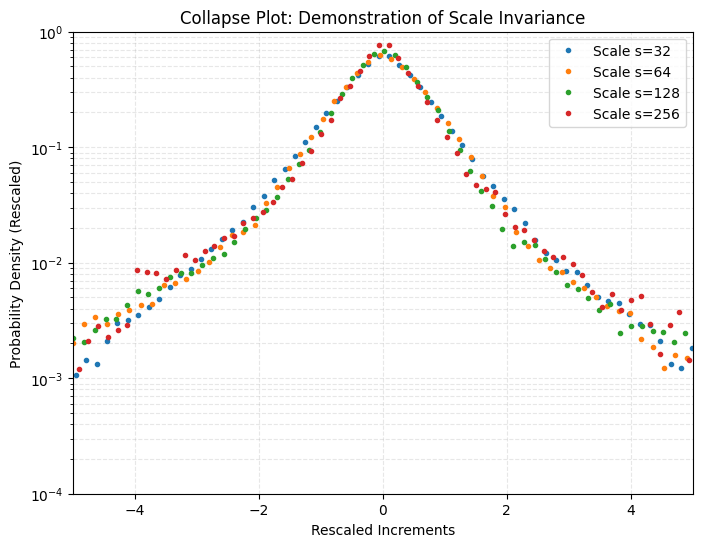

In [12]:
scales = [32, 64, 128, 256]
H = 1.0  # Hurst exponent for healthy heart is approx 1

first_record = list(B_data.keys())[0]

plt.figure(figsize=(8, 6))

for s in scales:
    # 1. Get the increments for this scale
    increments = get_detrended_increments(B_data[first_record], s=s, order=3)
    
    # 2. Rescale: Divide by s^H
    # This aligns the widths of the curves
    rescaled = increments / (s**H)
    
    # 3. Standardize (mean=0, std=1)
    std_rescaled = rescaled / np.std(rescaled)
    
    # 4. Build PDF
    counts, bin_edges = np.histogram(std_rescaled, bins=100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 5. Plot
    plt.plot(bin_centers, counts, 'o', markersize=3, label=f'Scale s={s}')

plt.yscale('log')
plt.ylim(1e-4, 1)
plt.xlim(-5, 5)
plt.title("Collapse Plot: Demonstration of Scale Invariance")
plt.xlabel("Rescaled Increments")
plt.ylabel("Probability Density (Rescaled)")
plt.legend()
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.show()